In [1]:
import logging
from math import sqrt

import matplotlib.pyplot as plt
import numpy as np
import optuna
import optuna.integration.lightgbm as lgb
import pandas as pd
import torch
from lightgbm import early_stopping
from scipy.stats import chi2, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.WARN)
logging.basicConfig(level=logging.WARNING)

# Kernelized Stein Discrepancy

In [2]:
def u_q(x_1, x_2, k, beta_0, h):
    # Calculate U-statistic based on kernel density estimation
    if h == float('inf'):
        return ((k / 2 - 1) / (x_1 - beta_0) - 0.5) * ((k / 2 - 1) / (x_2 - beta_0) - 0.5)
    else:
        return torch.exp(-(x_1 - x_2) ** 2 / 2 / (h ** 2)) * (
                ((k / 2 - 1) / (x_1 - beta_0) - 0.5) * ((k / 2 - 1) / (x_2 - beta_0) - 0.5) + (
                (k / 2 - 1) / (x_1 - beta_0) - (k / 2 - 1) / (x_2 - beta_0)) * (
                        x_1 - x_2) / h ** 2 + 1 / h ** 2 - (x_1 - x_2) ** 2 / h ** 4)

# Data Generation

In [3]:
def gen_data(n_train, n_test, k_x, train_dist, k_e, beta_0, linear_tree,
             uniform_l=None, uniform_r=None,
             n_clusters=None, cluster_centers=None, cluster_width=None):
    if train_dist == 'uniform':
        X = np.random.rand(n_train, k_x) * (uniform_r - uniform_l) + uniform_l
    elif train_dist == 'uniform_negative':
        X = np.random.rand(n_train, k_x) * uniform_r  # Generate random numbers in the range [0, r]
        # Flip the sign for values in the ranges [0, r/4] and [r/2, 3r/4]
        X = np.where((X >= 0) & (X <= uniform_r / 4), -X, X)
        X = np.where((X >= uniform_r / 2) & (X <= 3 * uniform_r / 4), -X, X)
    elif train_dist == 'uniform_cluster':
        # Vectorized approach to assign random clusters to each component of X
        cluster_indices = np.random.randint(0, n_clusters, size=(n_train, k_x))

        # Generate random numbers in the range of [-cluster_width, cluster_width]
        random_shifts = np.random.rand(n_train, k_x) * cluster_width - cluster_width / 2

        # Use np.take to handle 2D indexing with cluster_centers
        X = np.take(cluster_centers, cluster_indices) + random_shifts
    elif train_dist == 'normal':
        X = np.random.randn(n_train, k_x)
    else:
        raise NotImplementedError

    if k_e <= 0:
        y = np.sum(np.abs(X), axis=1) + beta_0
    else:
        y = np.sum(np.abs(X), axis=1) + beta_0 + np.sum(np.abs(np.random.randn(n_train, k_e)), axis=1)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

    X_test = np.random.randn(n_test, k_x)
    if k_e <= 0:
        y_test = np.sum(X_test ** 2, axis=1) + beta_0
    else:
        y_test = np.sum(X_test ** 2, axis=1) + beta_0 + np.random.chisquare(k_e, n_test)

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    params = {
        "objective": "regression",
        "metric": "mse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        'linear_tree': linear_tree,
    }

    model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data, val_data],
        callbacks=[early_stopping(100, verbose=False)],
    )

    y_train_hat = model.predict(X_train, num_iteration=model.best_iteration)
    y_val_hat = model.predict(X_val, num_iteration=model.best_iteration)
    y_test_hat = model.predict(X_test, num_iteration=model.best_iteration)
    mu_y = k_x + k_e + beta_0
    sigma_y = sqrt(2 * (k_x + k_e))
    return X_train, X_val, X_test, y_train, y_val, y_test, y_train_hat, y_val_hat, y_test_hat, mu_y, sigma_y

# Main Algorithm

In [4]:
def calibration(x, true_y, y_hat, mu_y, sigma_y, df, beta_0, y_left=-np.inf, y_right=np.inf, lamb=0.01,
                step_num=201, tolerance=20, bandwidth=3, device='cpu'):
    # Initialize y_test_hat_tensor
    y_test_hat_nonstan_tensor = torch.tensor(np.clip(y_hat, y_left, y_right), dtype=torch.float64, device=device,
                                             requires_grad=True)
    y_test_hat_nonstan_tensor = y_test_hat_nonstan_tensor.clone().detach().requires_grad_(True)
    y_test_hat_stan_tensor = torch.tensor(y_hat, dtype=torch.float64, device=device)
    y_test_hat_stan_tensor = torch.clip((y_test_hat_stan_tensor - torch.mean(y_test_hat_stan_tensor)) / torch.std(
        y_test_hat_stan_tensor) * sigma_y + mu_y, y_left, y_right)
    y_test_hat_stan_tensor = y_test_hat_stan_tensor.clone().detach().requires_grad_(True)

    with torch.no_grad():
        h_nonstan = bandwidth * torch.std(y_test_hat_nonstan_tensor).item()
        h_stan = bandwidth * torch.std(y_test_hat_stan_tensor).item()
        n_test = len(y_test_hat_stan_tensor)

    # Calculate raw and stan metrics
    raw_MSE = np.mean((y_hat - true_y) ** 2)

    y_test_hat_numpy_stan = y_test_hat_stan_tensor.detach().cpu().clone().numpy()
    stan_MSE = np.mean((y_test_hat_numpy_stan - true_y) ** 2)

    order = np.argsort(np.argsort(y_hat)) + 1
    quantile = chi2.ppf(order / (len(order) + 1), df) + beta_0

    raw_WDL = np.mean((np.sort(y_hat) - np.sort(true_y)) ** 2)
    stan_WDL = np.mean((np.sort(y_test_hat_numpy_stan) - np.sort(true_y)) ** 2)

    raw_dist_WDL = np.sum((quantile - y_hat) ** 2)
    stan_dist_WDL = np.sum((quantile - y_test_hat_numpy_stan) ** 2)

    raw_corr, _ = spearmanr(y_hat, true_y)
    stan_corr, _ = spearmanr(y_test_hat_numpy_stan, true_y)


    # Pre-calculate quantiles for dist_WDL
    quantile = np.sort(quantile)

    # Early stopping setup for different tolerances
    early_stopping_patience = {'stan': 0, 'nonstan': 0}
    best_results = {'stan': {'dist_wdl': np.mean((quantile - np.sort(y_test_hat_numpy_stan)) ** 2),
                             'best_test_y_hat': y_test_hat_stan_tensor.detach().cpu().clone().numpy()},
                    'nonstan': {
        'dist_wdl': np.mean((quantile - np.sort(y_test_hat_nonstan_tensor.detach().cpu().clone().numpy())) ** 2),
        'best_test_y_hat': y_test_hat_nonstan_tensor.detach().cpu().clone().numpy()}}


    for step in range(step_num):
        pairwise_values = u_q(y_test_hat_stan_tensor.unsqueeze(1), y_test_hat_stan_tensor.unsqueeze(0), df, beta_0,
                              h_stan)
        torch.diagonal(pairwise_values)[:] = 0
        test_statistic = torch.sum(pairwise_values) / sqrt(n_test)

        test_statistic.backward()
        gradient = y_test_hat_stan_tensor.grad
        gradient = torch.clip(gradient, -5 * torch.median(torch.abs(gradient)), 5 * torch.median(torch.abs(gradient)))

        with torch.no_grad():
            gradient /= torch.sqrt(torch.mean(gradient ** 2)) / torch.std(y_test_hat_stan_tensor)

            y_test_hat_stan_tensor -= lamb * gradient

        # Reset gradient for next iteration
        y_test_hat_stan_tensor.grad.zero_()

        # Calculate and store opt results for this step
        y_test_hat_numpy = y_test_hat_stan_tensor.detach().cpu().clone().numpy()

        opt_dist_WDL = np.mean((quantile - np.sort(y_test_hat_numpy)) ** 2)

        # Early stopping logic
        if opt_dist_WDL < best_results['stan']['dist_wdl']:  # Update best results if improvement
            best_results['stan'] = {
                'dist_wdl': opt_dist_WDL,
                'best_test_y_hat': y_test_hat_numpy
            }
            early_stopping_patience['stan'] = 0  # Reset patience if improvement
        else:
            early_stopping_patience['stan'] += 1  # Increment patience if no improvement

        # Trigger early stopping if no improvement for 'tol' steps
        if early_stopping_patience['stan'] >= tolerance:
            break

    for step in range(step_num):
        pairwise_values = u_q(y_test_hat_nonstan_tensor.unsqueeze(1), y_test_hat_nonstan_tensor.unsqueeze(0), df,
                              beta_0, h_nonstan)
        torch.diagonal(pairwise_values)[:] = 0
        test_statistic = torch.sum(pairwise_values) / sqrt(n_test)

        test_statistic.backward()
        gradient = y_test_hat_nonstan_tensor.grad
        gradient = torch.clip(gradient, -5 * torch.median(torch.abs(gradient)), 5 * torch.median(torch.abs(gradient)))

        with torch.no_grad():
            gradient /= torch.sqrt(torch.mean(gradient ** 2)) / torch.std(y_test_hat_nonstan_tensor)

            y_test_hat_nonstan_tensor -= lamb * gradient

        # Reset gradient for next iteration
        y_test_hat_nonstan_tensor.grad.zero_()

        # Calculate and store opt results for this step
        y_test_hat_numpy = y_test_hat_nonstan_tensor.detach().cpu().clone().numpy()

        opt_dist_WDL = np.mean((quantile - np.sort(y_test_hat_numpy)) ** 2)

        # Early stopping logic
        if opt_dist_WDL < best_results['nonstan']['dist_wdl']:  # Update best results if improvement
            best_results['nonstan'] = {
                'dist_wdl': opt_dist_WDL,
                'best_test_y_hat': y_test_hat_numpy
            }
            early_stopping_patience['nonstan'] = 0
        else:
            early_stopping_patience['nonstan'] += 1

        # Trigger early stopping if no improvement for 'tol' steps
        if early_stopping_patience['nonstan'] >= tolerance:
            break

    # Store the final results
    raw_results = (raw_MSE, raw_WDL, raw_dist_WDL, raw_corr)
    stan_results = (stan_MSE, stan_WDL, stan_dist_WDL, stan_corr)
    y_test_opt = best_results['stan']['best_test_y_hat']
    opt_MSE = np.mean((y_test_opt - true_y) ** 2)
    opt_WDL = np.mean((np.sort(y_test_opt) - np.sort(true_y)) ** 2)
    opt_dist_WDL = best_results['stan']['dist_wdl']
    opt_corr, _ = spearmanr(y_test_opt, true_y)
    opt_results = (opt_MSE, opt_WDL, opt_dist_WDL, opt_corr)
    y_test_nonstan_opt = best_results['nonstan']['best_test_y_hat']
    opt_nonstan_MSE = np.mean((y_test_nonstan_opt - true_y) ** 2)
    opt_nonstan_WDL = np.mean((np.sort(y_test_nonstan_opt) - np.sort(true_y)) ** 2)
    opt_nonstan_dist_WDL = best_results['nonstan']['dist_wdl']
    opt_nonstan_corr, _ = spearmanr(y_test_nonstan_opt, true_y)
    opt_nonstan_results = (opt_nonstan_MSE, opt_nonstan_WDL, opt_nonstan_dist_WDL, opt_nonstan_corr)

    return raw_results, stan_results, opt_results, opt_nonstan_results

# Results

In [5]:
def get_results(n_train, n_test, k_x, train_dist, k_e, beta_0, linear_tree, uniform_l, uniform_r, n_clusters,
                cluster_centers, cluster_width, lamb, step_num, tolerance, bandwidth, test_sample, device):
    results_df = None

    for i in range(test_sample):
        X_train, X_val, X_test, y_train, y_val, y_test, y_train_hat, y_val_hat, y_test_hat, mu_y, \
            sigma_y = gen_data(n_train, n_test, k_x, train_dist, k_e, beta_0, linear_tree, uniform_l, uniform_r,
                               n_clusters, cluster_centers, cluster_width)

        raw_results, stan_results, opt_results, \
            opt_nonstan_results = calibration(X_test, y_test, y_test_hat, mu_y, sigma_y, k_x + k_e, beta_0, beta_0 + 1e-3,
                                              np.inf, lamb, step_num, tolerance, bandwidth, device)

        results = {
            'n_train': n_train,
            'n_test': n_test,
            'raw_MSE': raw_results[0],
            'raw_WDL': raw_results[1],
            'raw_dist_WDL': raw_results[2],
            'raw_corr': raw_results[3],
            'stan_MSE': stan_results[0],
            'stan_WDL': stan_results[1],
            'stan_dist_WDL': stan_results[2],
            'stan_corr': stan_results[3],
            'opt_MSE': opt_results[0],
            'opt_WDL': opt_results[1],
            'opt_dist_WDL': opt_results[2],
            'opt_corr': opt_results[3],
            'opt_nonstan_MSE': opt_nonstan_results[0],
            'opt_nonstan_WDL': opt_nonstan_results[1],
            'opt_nonstan_dist_WDL': opt_nonstan_results[2],
            'opt_nonstan_corr': opt_nonstan_results[3],
        }

        if results_df is None:
            results_df = pd.DataFrame([results])
        else:
            results_df = pd.concat([results_df, pd.DataFrame([results])], ignore_index=True)

    return results_df

In [6]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [7]:
k_x = 5
train_dist = 'uniform'
k_e = 1
beta_0 = 5
linear_tree = False
uniform_l = -2
uniform_r = 2
n_clusters = None
cluster_centers = None
cluster_width = None
lamb = 0.01
step_num = 201
bandwidth = 3
tolerance = 20
test_sample = 15

In [8]:
n_train = 100
n_test = 1000
results_df = get_results(n_train, n_test, k_x, train_dist, k_e, beta_0, linear_tree, uniform_l, uniform_r,
                         n_clusters, cluster_centers, cluster_width, lamb, step_num, tolerance, bandwidth,
                         test_sample, device)

min_child_samples, val_score: 1.105053: 100%|############################################| 5/5 [00:00<00:00, 28.00it/s]


In [9]:
n_train = 1000
n_test = 1000
results_df2 = get_results(n_train, n_test, k_x, train_dist, k_e, beta_0, linear_tree, uniform_l, uniform_r,
                            n_clusters, cluster_centers, cluster_width, lamb, step_num, tolerance, bandwidth,
                            test_sample, device)

min_child_samples, val_score: 0.363066: 100%|############################################| 5/5 [00:00<00:00,  6.12it/s]


In [10]:
results_df = pd.concat([results_df, results_df2], ignore_index=True)

# Figure 3

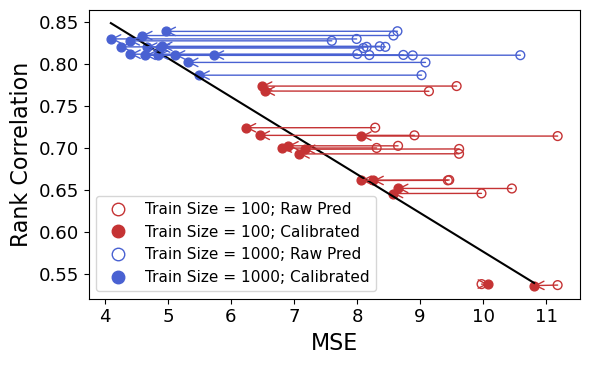

In [11]:
# Define color mapping using coolwarm colormap with adjusted colors
cmap = plt.get_cmap('coolwarm')
color_map = {100: cmap(0.95), 300: cmap(0.35), 1000: cmap(0.05)}  # Adjusted for visibility

plt.figure(figsize=(6, 5 / 8 * 6))

# Plot raw_MSE vs raw_corr with hollow markers and draw arrows
for n_train, group in results_df.groupby('n_train'):
    color = color_map[n_train]
    # Plot hollow markers
    plt.scatter(group['raw_MSE'], group['raw_corr'], edgecolor=color, facecolor='none', s=40)
    # Plot solid markers
    plt.scatter(group['opt_MSE'], group['opt_corr'], color=color, s=40)

    # Draw arrows between the first two points for each n_train group
    if len(group) >= 2:
        for i in range(len(group)):
            plt.annotate(
                '',
                xy=(group['opt_MSE'].iloc[i], group['opt_corr'].iloc[i]),
                xytext=(group['raw_MSE'].iloc[i], group['raw_corr'].iloc[i]),
                arrowprops=dict(facecolor=color, edgecolor=color, arrowstyle='->', lw=1, shrinkA=0, shrinkB=0,
                                mutation_scale=15)
            )

    # Linear regression for each group
    # model = LinearRegression()
    # X = group['raw_MSE'].values.reshape(-1, 1)
    # y = group['raw_corr'].values
    # model.fit(X, y)
    # x_range = np.linspace(X.min(), X.max(), 100)
    # y_pred = model.predict(x_range.reshape(-1, 1))
    # plt.plot(x_range, y_pred, linestyle='--', color=color)

# Linear regression for all opt_MSE and opt_corr
model = LinearRegression()
X = results_df['opt_MSE'].values.reshape(-1, 1)
y = results_df['opt_corr'].values
model.fit(X, y)
x_range = np.linspace(X.min(), X.max(), 100)
y_pred = model.predict(x_range.reshape(-1, 1))
plt.plot(x_range, y_pred, linestyle='-', color='black')


# plt.title('Effects of calibration on predication’s alignment with ground truth', fontsize=11.5)
plt.xlabel('MSE', fontsize=16)
plt.xticks(fontsize=13)
plt.ylabel('Rank Correlation', fontsize=16)
plt.yticks(fontsize=13)

# Custom legend entries to match the plot markers
custom_lines = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor=cmap(0.95), markersize=9,
               linestyle='none', label='Train Size = 100; Raw Pred'),
    plt.Line2D([0], [0], marker='o', color=cmap(0.95), markersize=9, linestyle='none',
               label='Train Size = 100; Calibrated'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor=cmap(0.05), markersize=9,
               linestyle='none', label='Train Size = 1000; Raw Pred'),
    plt.Line2D([0], [0], marker='o', color=cmap(0.05), markersize=9, linestyle='none',
               label='Train Size = 1000; Calibrated')
]
plt.legend(handles=custom_lines, loc='best', fontsize=11)

plt.tight_layout()
plt.savefig('fig/MSEvscorr.pdf')
plt.show()